# Stiffness ratios in 2D

In [31]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.linalg import eigh, solve
from scipy.interpolate import BarycentricInterpolator

from discretization import Discretization
from utils import make_boundary_hhalf_matrix_numpy

In [32]:
mpl.rcParams.update(
    {
        "font.size": 18,
        "axes.labelsize": 18,
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
        "legend.fontsize": 15,
        "lines.linewidth": 3,
    }
)

degrees = np.arange(1, 61)
cache_path = Path("results/stiffness_ratios_2d.csv")

if cache_path.exists():
    results = pd.read_csv(cache_path)
    run_degrees = []
    print(f"Loaded results from {cache_path}")
else:
    run_degrees = degrees
    print("No cached results found.")

No cached results found.


In [33]:
results = []

for degree in run_degrees:

    # --- Discretization ---
    disc = Discretization((degree, degree))
    disc.init_boundary_quadrature()

    x, y = disc.x
    wx, wy = disc.w

    Dx, Dy = disc.nabla
    W = disc.W
    X_bc = disc.X_bc
    W_bc = disc.W_bc

    Hmat = disc.Hmat
    Hmat_s = disc.Hmat_s

    # --- Laplacian and H1 inner product ---
    Dxx = Dx @ Dx
    Dyy = Dy @ Dy
    Lap = Dxx + Dyy

    B_H1 = W @ Hmat
    B_H1 = 0.5 * (B_H1 + B_H1.T)

    # --- Trace matrix ---
    Ix = np.eye(len(x))
    Iy = np.eye(len(y))

    interp_x = BarycentricInterpolator(x, Ix, axis=0)
    interp_y = BarycentricInterpolator(y, Iy, axis=0)

    trace_x_left = interp_x(-1.0)[None, :]
    trace_x_right = interp_x(1.0)[None, :]
    trace_y_bottom = interp_y(-1.0)[None, :]
    trace_y_top = interp_y(1.0)[None, :]

    T_left = np.kron(trace_x_left, Iy)
    T_right = np.kron(trace_x_right, Iy)
    T_bottom = np.kron(Ix, trace_y_bottom)
    T_top = np.kron(Ix, trace_y_top)

    T_lr = np.stack([T_left, T_right], axis=1).reshape(-1, disc.N)
    T_bt = np.stack([T_bottom, T_top], axis=1).reshape(-1, disc.N)

    T_bc = np.vstack([T_lr, T_bt])

    # --- Boundary residual matrices ---
    W_bc_half = make_boundary_hhalf_matrix_numpy(
        X_bc,
        W_bc,
        boundary_dim=1,
    )

    A_bc_mse = (T_bc.T @ T_bc) / len(disc.X_bc)
    A_bc_l2 = T_bc.T @ disc.W_bc @ T_bc
    A_bc_half = T_bc.T @ W_bc_half @ T_bc

    # --- PDE residual matrices ---
    A_pde_mse = (Lap.T @ Lap) / disc.N
    A_pde_l2 = Lap.T @ W @ Lap
    A_pde_sinos = Lap.T @ W @ solve(Hmat, Lap)
    A_pde_dsinos = Lap.T @ W @ solve(Hmat_s, Lap)

    # --- Combined residual matrices ---
    # Original formulations
    A_mse = A_pde_mse + A_bc_mse
    A_l2 = A_pde_l2 + A_bc_l2
    A_sinos = A_pde_sinos + A_bc_half
    A_dsinos = A_pde_dsinos + A_bc_half

    # MSE interior
    A_mse_l2 = A_pde_mse + A_bc_l2
    A_mse_half = A_pde_mse + A_bc_half

    # L2 interior
    A_l2_mse = A_pde_l2 + A_bc_mse
    A_l2_half = A_pde_l2 + A_bc_half

    # SINOS interior
    A_sinos_mse = A_pde_sinos + A_bc_mse
    A_sinos_l2 = A_pde_sinos + A_bc_l2

    # D-SINOS interior
    A_dsinos_mse = A_pde_dsinos + A_bc_mse
    A_dsinos_l2 = A_pde_dsinos + A_bc_l2

    # --- Symmetrize matrices ---

    # Original formulations
    A_mse = 0.5 * (A_mse + A_mse.T)
    A_l2 = 0.5 * (A_l2 + A_l2.T)
    A_sinos = 0.5 * (A_sinos + A_sinos.T)
    A_dsinos = 0.5 * (A_dsinos + A_dsinos.T)

    # MSE interior ablations
    A_mse_l2 = 0.5 * (A_mse_l2 + A_mse_l2.T)
    A_mse_half = 0.5 * (A_mse_half + A_mse_half.T)

    # L2 interior ablations
    A_l2_mse = 0.5 * (A_l2_mse + A_l2_mse.T)
    A_l2_half = 0.5 * (A_l2_half + A_l2_half.T)

    # SINOS interior ablations
    A_sinos_mse = 0.5 * (A_sinos_mse + A_sinos_mse.T)
    A_sinos_l2 = 0.5 * (A_sinos_l2 + A_sinos_l2.T)

    # D-SINOS interior ablations
    A_dsinos_mse = 0.5 * (A_dsinos_mse + A_dsinos_mse.T)
    A_dsinos_l2 = 0.5 * (A_dsinos_l2 + A_dsinos_l2.T)

    # --- Extremal generalized eigenvalues relative to H1 ---

    # Original formulations
    i_max = disc.N - 1

    C0_mse = eigh(A_mse, B_H1, eigvals_only=True, subset_by_index=[0, 0])[0]
    C1_mse = eigh(A_mse, B_H1, eigvals_only=True, subset_by_index=[i_max, i_max])[0]

    C0_l2 = eigh(A_l2, B_H1, eigvals_only=True, subset_by_index=[0, 0])[0]
    C1_l2 = eigh(A_l2, B_H1, eigvals_only=True, subset_by_index=[i_max, i_max])[0]

    C0_sinos = eigh(A_sinos, B_H1, eigvals_only=True, subset_by_index=[0, 0])[0]
    C1_sinos = eigh(A_sinos, B_H1, eigvals_only=True, subset_by_index=[i_max, i_max])[0]

    C0_dsinos = eigh(A_dsinos, B_H1, eigvals_only=True, subset_by_index=[0, 0])[0]
    C1_dsinos = eigh(A_dsinos, B_H1, eigvals_only=True, subset_by_index=[i_max, i_max])[
        0
    ]

    # MSE interior ablations
    C0_mse_l2 = eigh(A_mse_l2, B_H1, eigvals_only=True, subset_by_index=[0, 0])[0]
    C1_mse_l2 = eigh(A_mse_l2, B_H1, eigvals_only=True, subset_by_index=[i_max, i_max])[
        0
    ]

    C0_mse_half = eigh(A_mse_half, B_H1, eigvals_only=True, subset_by_index=[0, 0])[0]
    C1_mse_half = eigh(
        A_mse_half, B_H1, eigvals_only=True, subset_by_index=[i_max, i_max]
    )[0]

    # L2 interior ablations
    C0_l2_mse = eigh(A_l2_mse, B_H1, eigvals_only=True, subset_by_index=[0, 0])[0]
    C1_l2_mse = eigh(A_l2_mse, B_H1, eigvals_only=True, subset_by_index=[i_max, i_max])[
        0
    ]

    C0_l2_half = eigh(A_l2_half, B_H1, eigvals_only=True, subset_by_index=[0, 0])[0]
    C1_l2_half = eigh(
        A_l2_half, B_H1, eigvals_only=True, subset_by_index=[i_max, i_max]
    )[0]

    # SINOS interior ablations
    C0_sinos_mse = eigh(A_sinos_mse, B_H1, eigvals_only=True, subset_by_index=[0, 0])[0]
    C1_sinos_mse = eigh(
        A_sinos_mse, B_H1, eigvals_only=True, subset_by_index=[i_max, i_max]
    )[0]

    C0_sinos_l2 = eigh(A_sinos_l2, B_H1, eigvals_only=True, subset_by_index=[0, 0])[0]
    C1_sinos_l2 = eigh(
        A_sinos_l2, B_H1, eigvals_only=True, subset_by_index=[i_max, i_max]
    )[0]

    # D-SINOS interior ablations
    C0_dsinos_mse = eigh(A_dsinos_mse, B_H1, eigvals_only=True, subset_by_index=[0, 0])[
        0
    ]
    C1_dsinos_mse = eigh(
        A_dsinos_mse, B_H1, eigvals_only=True, subset_by_index=[i_max, i_max]
    )[0]

    C0_dsinos_l2 = eigh(A_dsinos_l2, B_H1, eigvals_only=True, subset_by_index=[0, 0])[0]
    C1_dsinos_l2 = eigh(
        A_dsinos_l2, B_H1, eigvals_only=True, subset_by_index=[i_max, i_max]
    )[0]

    results.append(
        {
            "degree": degree,
            "N": disc.N,
            # Original formulations
            "MSE C0": C0_mse,
            "MSE C1": C1_mse,
            "MSE ratio": C1_mse / C0_mse,
            "L2 C0": C0_l2,
            "L2 C1": C1_l2,
            "L2 ratio": C1_l2 / C0_l2,
            "SINOS C0": C0_sinos,
            "SINOS C1": C1_sinos,
            "SINOS ratio": C1_sinos / C0_sinos,
            "D-SINOS C0": C0_dsinos,
            "D-SINOS C1": C1_dsinos,
            "D-SINOS ratio": C1_dsinos / C0_dsinos,
            # MSE interior ablations
            "MSE-L2 ratio": C1_mse_l2 / C0_mse_l2,
            "MSE-Half ratio": C1_mse_half / C0_mse_half,
            # L2 interior ablations
            "L2-MSE ratio": C1_l2_mse / C0_l2_mse,
            "L2-Half ratio": C1_l2_half / C0_l2_half,
            # SINOS interior ablations
            "SINOS-MSE ratio": C1_sinos_mse / C0_sinos_mse,
            "SINOS-L2 ratio": C1_sinos_l2 / C0_sinos_l2,
            # D-SINOS interior ablations
            "D-SINOS-MSE ratio": C1_dsinos_mse / C0_dsinos_mse,
            "D-SINOS-L2 ratio": C1_dsinos_l2 / C0_dsinos_l2,
        }
    )

results = pd.DataFrame(results)
cache_path.parent.mkdir(parents=True, exist_ok=True)

results.to_csv(
    cache_path,
    index=False,
    float_format="%.17g",
)

print(f"Saved results to {cache_path}")

Saved results to results/stiffness_ratios_2d.csv


In [34]:
# --- Fit exponents to the tail of the data ---
tail = results["degree"] >= np.max(degrees) / 2

p_mse = np.polyfit(
    np.log(results.loc[tail, "degree"]), np.log(results.loc[tail, "MSE ratio"]), 1
)[0]
p_l2 = np.polyfit(
    np.log(results.loc[tail, "degree"]), np.log(results.loc[tail, "L2 ratio"]), 1
)[0]
p_sinos = np.polyfit(
    np.log(results.loc[tail, "degree"]), np.log(results.loc[tail, "SINOS ratio"]), 1
)[0]
p_dsinos = np.polyfit(
    np.log(results.loc[tail, "degree"]), np.log(results.loc[tail, "D-SINOS ratio"]), 1
)[0]

print(f"MSE exponent:      {p_mse:.2f}")
print(f"L2 exponent:       {p_l2:.2f}")
print(f"SINOS exponent:   {p_sinos:.2f}")
print(f"D-SINOS exponent: {p_dsinos:.2f}")

MSE exponent:      6.95
L2 exponent:       5.68
SINOS exponent:   2.00
D-SINOS exponent: 0.05


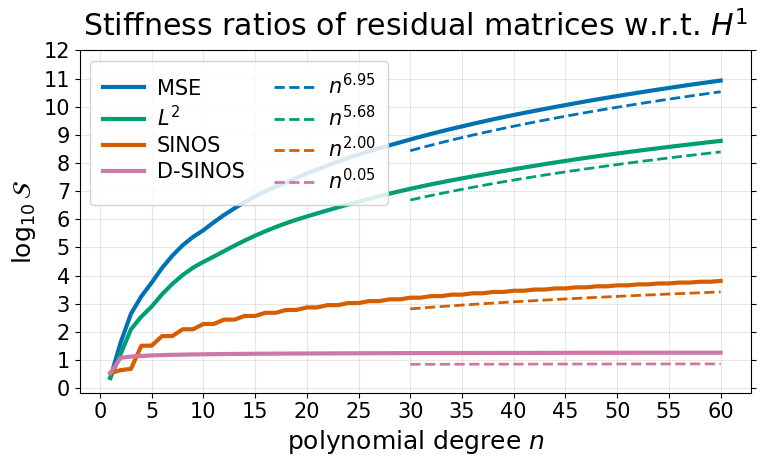

In [37]:
# --- Plot stiffness ratios ---
plt.style.use("seaborn-v0_8-colorblind")
plt.figure(figsize=(8, 5))

(line_mse,) = plt.plot(results["degree"], np.log10(results["MSE ratio"]), label=r"MSE")

(line_l2,) = plt.plot(results["degree"], np.log10(results["L2 ratio"]), label=r"$L^2$")

(line_sinos,) = plt.plot(
    results["degree"], np.log10(results["SINOS ratio"]), label="SINOS"
)

(line_dsinos,) = plt.plot(
    results["degree"], np.log10(results["D-SINOS ratio"]), label="D-SINOS"
)


# --- Reference rates ---
n_fit = results.loc[tail, "degree"].to_numpy()

for column, p, line in [
    ("MSE ratio", p_mse, line_mse),
    ("L2 ratio", p_l2, line_l2),
    ("SINOS ratio", p_sinos, line_sinos),
    ("D-SINOS ratio", p_dsinos, line_dsinos),
]:
    n0 = n_fit[0]
    y0 = results.loc[tail, column].iloc[0]

    # slightly shift reference line so it remains visible
    y_fit = 0.4 * y0 * (n_fit / n0) ** p

    plt.plot(
        n_fit,
        np.log10(y_fit),
        "--",
        color=line.get_color(),
        linewidth=2,
        label=rf"$n^{{{p:.2f}}}$",
    )
plt.title(rf"Stiffness ratios of residual matrices w.r.t. $H^1$", pad=10)
plt.xlabel(r"polynomial degree $n$")
plt.ylabel(r"$\log_{10} \mathcal{S}$")
plt.xticks(np.arange(0, 61, 5))
plt.yticks(np.arange(0, 13, step=1))
ax = plt.gca()
ax.tick_params(axis="y", which="both", left=True, right=True)
plt.legend(
    loc="upper left",
    ncol=2,
    columnspacing=1.4,
    handlelength=2.0,
    handletextpad=0.6,
    labelspacing=0.3,
    borderpad=0.6,
    frameon=True,
    framealpha=0.85,
)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("media/stiffness_ratios_2d.pdf", bbox_inches="tight")
plt.show()